# Project: Low-Rank Approximation
**Numerical Linear Algebra**  
**Data:** retail company clients' transaction history

---
## Hypothesis

> The customer × product category purchase matrix at Korzinka has low-rank structure — the behavior of hundreds of thousands of customers can be explained by a small number of latent consumption patterns.

If confirmed, a rank-$k$ approximation $A_k = U_k \Sigma_k V_k^\top$ with $k \ll \min(\text{customers}, \text{categories})$ recovers $A$ well in the Frobenius norm.
The **Eckart–Young theorem** guarantees SVD gives the best such approximation:

$$\min_{\text{rank}(B) \leq k} \|A - B\|_F = \|A - A_k\|_F = \sqrt{\sum_{i=k+1}^{r} \sigma_i^2}$$

The matrix $A$ has dimensions $(\text{customers}) \times (\text{categories})$, where each entry is the total spend by a given customer in a given product category over the observation period. The matrix is **large and sparse**.

### Data & Sampling

- **Source:** clients retail transaction history (Microsoft Fabric)
- **Period:** 2025-01-01 — 2025-12-31 (full calendar year)
- **Customers:** loyalty card holders only, sampled to **~300K clients** with at least 5 purchases during the period
- **Products:** aggregated to **level-5 product categories** (498 categories) instead of raw SKUs (20,000), giving a denser and more interpretable matrix
- **Value:** `SUM(rcpt_line_tot_amt)` — total spend per (customer, category) pair
- **Excluded categories:** non-behavioral items (bags)

### Resulting Matrix

| Dimension | Value |
|---|---|
| Customers | 300,395 |
| Categories | 498 |
| Non-zero entries | 20,513,291 |
| Density | 13.71% |

---
## Experimental Steps

| # | Step | Description |
|---|------|-------------|
| 1 | **Build the Matrix** | Aggregate transactions into a sparse customer × category matrix $A$. Record shape and density. |
| 2 | **Spectral Analysis** | Compute top $K \approx 200$–$300$ singular values. Plot decay and cumulative energy. |
| 3 | **Approximation Error Curve** | For $k = 1, 5, 10, 20, 50, 100, \ldots$ compute relative Frobenius error. Find $k$ for <10% and <5% error. |
| 4 | **Pattern Interpretation** | Inspect top 5–7 right singular vectors. List 15 highest-weight categories per pattern. |
| 5 | **Customer Space Visualization** | Project customers onto first two patterns. Scatter plot reveals natural clusters. |
| 6 | **Randomized vs. Exact SVD** | Benchmark Halko–Martinsson–Tropp randomized SVD vs truncated exact SVD. |

### Post-Analysis: Making Results Tangible

- **Heatmap before/after:** small slice (100 customers × 50 categories) of $A$ vs $A_k$ side-by-side
- **Latent pattern profiles:** bar charts of top-15 categories per singular vector — patterns we expect to find in grocery retail:
  - *Pattern 1* (largest $\sigma_1$): staples (bread, dairy, oils) — universal basket
  - *Pattern 2*: baby food, diapers, infant formula — young families
  - *Pattern 3*: wine, premium deli, cheese — premium / weekend shoppers
  - *Pattern 4*: snacks, energy drinks, ready meals — young singles
- **Customer scatter plot:** 2D projection onto first two components, clusters emerge without any clustering algorithm
- **Customer portrait:** one specific customer — top categories, pattern coordinates, dominant pattern

### Written Report Structure

1. **Introduction** — problem statement, motivation, dataset description
2. **Mathematical Background** — SVD, Eckart–Young theorem, norm choice, randomized SVD
3. **Data & Setup** — matrix construction, shape, sparsity, preprocessing
4. **Experiments** — steps 2–6: plots, tables, numerical results
5. **Interpretation** — latent consumption patterns, customer portraits
6. **Conclusion** — hypothesis verdict, practical implications, limitations

In [ ]:
#!pip install pandas numpy scipy scikit-learn matplotlib seaborn
#!pip install pandas pyarrow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.utils.extmath import randomized_svd
import time
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import glob
import zipfile
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


zip_path = "/content/drive/MyDrive/Datasets.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
import pandas as pd
import glob

# Get a list of all parquet files in the directory
parquet_files = glob.glob("/content/data/*.parquet")

# Read each parquet file into a DataFrame and concatenate them
dfs = [pd.read_parquet(file) for file in parquet_files]
df = pd.concat(dfs, ignore_index=True)

df.head()

,loy_card_cd,level_5,name_level_5,total_amt
0,9909966020118,129060105,Бритвенные Принадлежности,14980.00
1,9909939167246,131060002,Письменные Принадлежности,21990.00
2,9909984174978,137050102,Коктейли Молочные,6990.00
3,1111205250806,115020304,Колбаса Полу-Копченая,77990.00
4,9909987377291,122000017,Свекла,2732.58


---
## Step 1 — Build the Matrix

In [ ]:
from scipy.sparse import csr_matrix
import pandas as pd
import numpy as np

# Aggregate
agg = (
    df.groupby(['loy_card_cd', 'level_5'])['total_amt']
    .sum()
    .reset_index()
    .rename(columns={'total_amt': 'total_amount'})
)

# Convert amount to numeric
agg['total_amount'] = pd.to_numeric(agg['total_amount'], errors='coerce')
agg = agg.dropna(subset=['total_amount'])

# Encode IDs
agg['customer_idx'] = agg['loy_card_cd'].astype('category').cat.codes.astype(np.int64)
agg['category_idx'] = agg['level_5'].astype('category').cat.codes.astype(np.int64)

n_customers = int(agg['customer_idx'].max()) + 1
n_categories = int(agg['category_idx'].max()) + 1

# Build sparse matrix
A = csr_matrix(
    (
        agg['total_amount'].astype(np.float64).values,
        (
            agg['customer_idx'].values.astype(np.int64),
            agg['category_idx'].values.astype(np.int64)
        )
    ),
    shape=(n_customers, n_categories)
)

density = A.nnz / (float(n_customers) * float(n_categories))

print(f"Matrix shape : {A.shape}")
print(f"Non-zeros    : {A.nnz:,}")
print(f"Density      : {density:.4%}")

Matrix shape : (300395, 498)
Non-zeros    : 19,688,644
Density      : 13.1611%


---
## Step 2 — Spectral Analysis

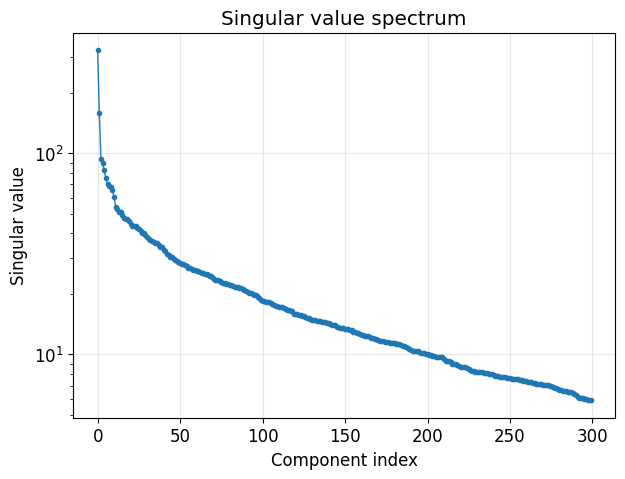

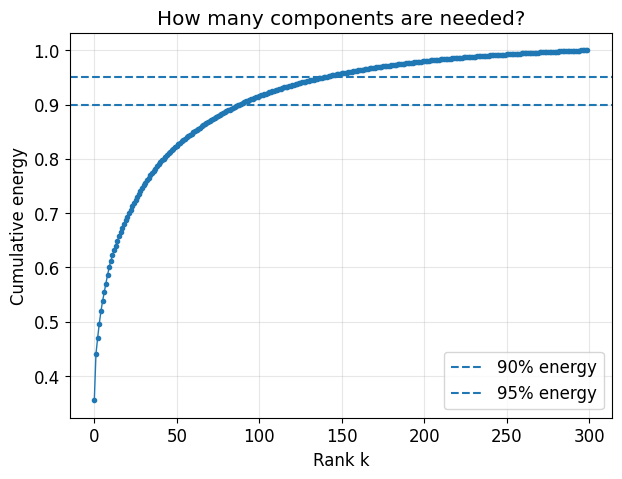

K used: 300
Rank for 90% energy: 89
Rank for 95% energy: 140


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd
from sklearn.preprocessing import normalize

A_normalized = normalize(A, norm='l2', axis=1) #try without normalization, the second plot doesn't look meaningful without it
# Choose rank safely
K = min(300, A.shape[1] - 1)

# Randomized SVD on sparse customer-category matrix
U, sigma, Vt = randomized_svd(A_normalized, n_components=K, random_state=42)
"""U, sigma, Vt = randomized_svd(
    A,
    n_components=K,
    random_state=42
)"""

# Explained energy
energy = np.cumsum(sigma**2) / np.sum(sigma**2)

# Plot singular values
plt.figure(figsize=(7, 5))
plt.plot(sigma, 'o-', markersize=3, linewidth=1)
plt.xlabel('Component index')
plt.ylabel('Singular value')
plt.title('Singular value spectrum')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Plot cumulative energy
plt.figure(figsize=(7, 5))
plt.plot(energy, 'o-', markersize=3, linewidth=1)
plt.axhline(0.90, linestyle='--', label='90% energy')
plt.axhline(0.95, linestyle='--', label='95% energy')
plt.xlabel('Rank k')
plt.ylabel('Cumulative energy')
plt.title('How many components are needed?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Suggested ranks
k_90 = np.argmax(energy >= 0.90) + 1
k_95 = np.argmax(energy >= 0.95) + 1

print(f"K used: {K}")
print(f"Rank for 90% energy: {k_90}")
print(f"Rank for 95% energy: {k_95}")

---
## Step 3 — Approximation Error Curve

k =    1  ||A - A_k||_F / ||A||_F = 0.8028
k =    5  ||A - A_k||_F / ||A||_F = 0.6936
k =   10  ||A - A_k||_F / ||A||_F = 0.6324
k =   20  ||A - A_k||_F / ||A||_F = 0.5595
k =   50  ||A - A_k||_F / ||A||_F = 0.4225
k =  100  ||A - A_k||_F / ||A||_F = 0.2921
k =  150  ||A - A_k||_F / ||A||_F = 0.2084
k =  200  ||A - A_k||_F / ||A||_F = 0.1433
k =  300  ||A - A_k||_F / ||A||_F = 0.0000


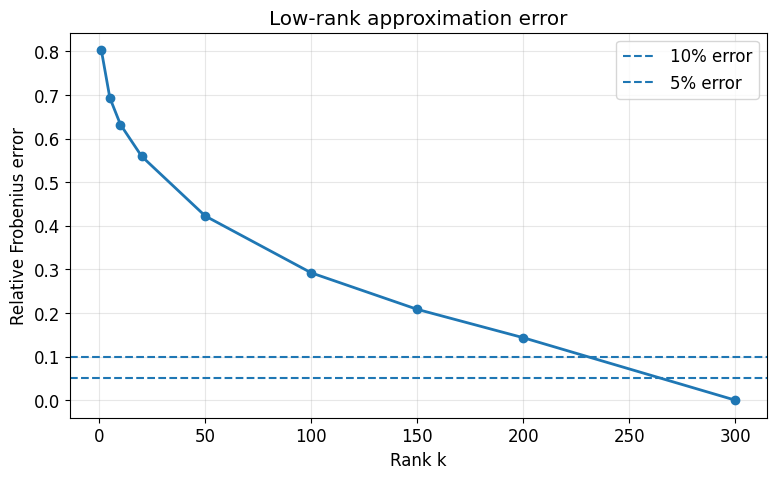

In [ ]:
# Using the sigma from SVD on A_normalized, not raw A

ks = [1, 5, 10, 20, 50, 100, 150, 200, 300]
ks = [k for k in ks if k <= len(sigma)]

total_energy = np.sum(sigma**2)
errors = []

for k in ks:
    explained_energy = np.sum(sigma[:k]**2) / total_energy
    rel_err = np.sqrt(1 - explained_energy)
    errors.append(rel_err)
    print(f"k = {k:4d}  ||A - A_k||_F / ||A||_F = {rel_err:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(ks, errors, 'o-', linewidth=2)
plt.axhline(0.10, linestyle='--', label='10% error')
plt.axhline(0.05, linestyle='--', label='5% error')
plt.xlabel('Rank k')
plt.ylabel('Relative Frobenius error')
plt.title('Low-rank approximation error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Step 4 — Pattern Interpretation

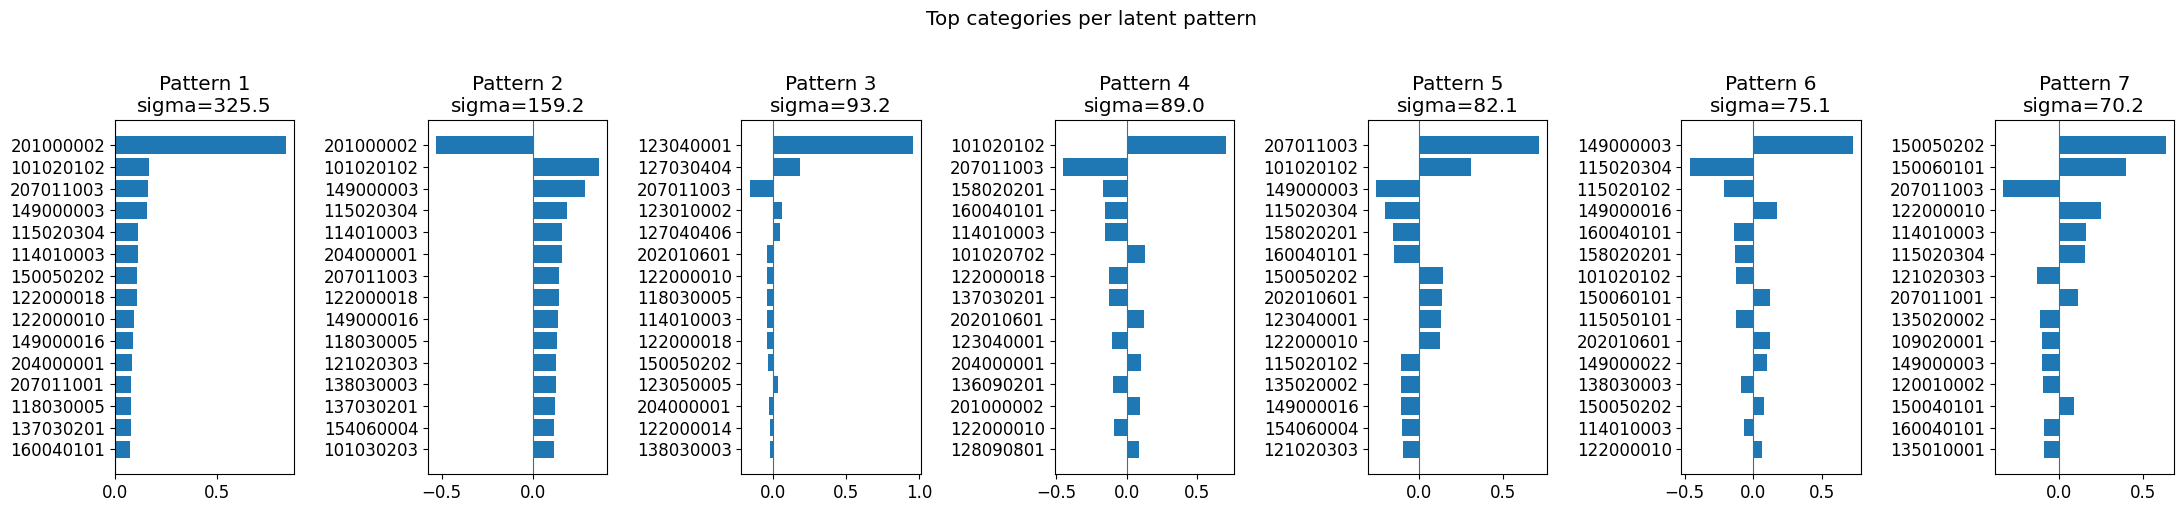

'N_PATTERNS = 7\nTOP_N = 15\n\n# Recreate category mappings if they are missing\ncategory_cat = agg[\'level_5\'].astype(\'category\')\nidx_to_category = dict(enumerate(category_cat.cat.categories))\n\n# Optional: readable category names\ncategory_names = df[[\'level_5\', \'name_level_5\']].drop_duplicates()\ncategory_dict = dict(zip(category_names[\'level_5\'], category_names[\'name_level_5\']))\n\nidx_to_category_name = {\n    idx: category_dict.get(cat, str(cat))\n    for idx, cat in idx_to_category.items()\n}\n\n# Make sure we do not request more patterns than available\nN_PATTERNS = min(N_PATTERNS, Vt.shape[0])\n\nfig, axes = plt.subplots(1, N_PATTERNS, figsize=(22, 5))\n\nif N_PATTERNS == 1:\n    axes = [axes]\n\nfor i in range(N_PATTERNS):\n    vec = Vt[i]\n\n    top_idx = np.argsort(np.abs(vec))[-TOP_N:][::-1]\n    top_weights = vec[top_idx]\n\n    top_labels = [\n        idx_to_category_name.get(j, str(j))[:30]\n        for j in top_idx\n    ]\n\n    axes[i].barh(top_labels[::-

In [ ]:
N_PATTERNS = 7
TOP_N = 15

fig, axes = plt.subplots(1, N_PATTERNS, figsize=(22, 5))

for i in range(N_PATTERNS):
    vec = Vt[i]

    # Get top contributing categories
    top_idx = np.argsort(np.abs(vec))[-TOP_N:][::-1]
    top_weights = vec[top_idx]

    # Map indices to category IDs
    top_labels = [str(idx_to_category.get(j, j)) for j in top_idx]

    axes[i].barh(top_labels[::-1], top_weights[::-1])
    axes[i].set_title(f'Pattern {i+1}\nsigma={sigma[i]:.1f}')
    axes[i].axvline(0, linewidth=0.8)

plt.suptitle('Top categories per latent pattern', y=1.02)
plt.tight_layout()
plt.show()





---
## Step 5 — Customer Space Visualization

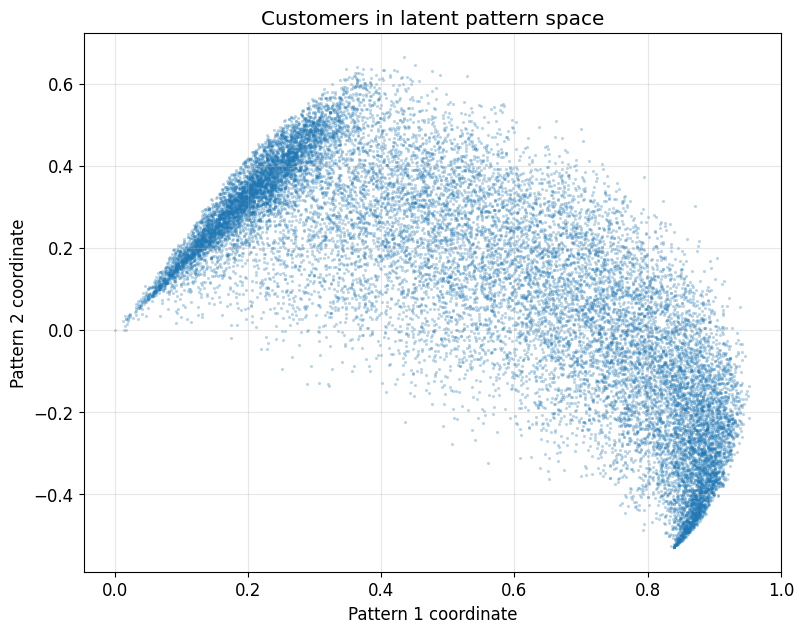

In [ ]:
coords = U[:, :2] * sigma[:2]

N_SAMPLE = min(20_000, coords.shape[0])
idx_sample = np.random.choice(coords.shape[0], N_SAMPLE, replace=False)

plt.figure(figsize=(9, 7))
plt.scatter(
    coords[idx_sample, 0],
    coords[idx_sample, 1],
    alpha=0.3,
    s=5,
    linewidths=0
)
plt.xlabel('Pattern 1 coordinate')
plt.ylabel('Pattern 2 coordinate')
plt.title('Customers in latent pattern space')
plt.grid(True, alpha=0.3)
plt.show()

## Clustering


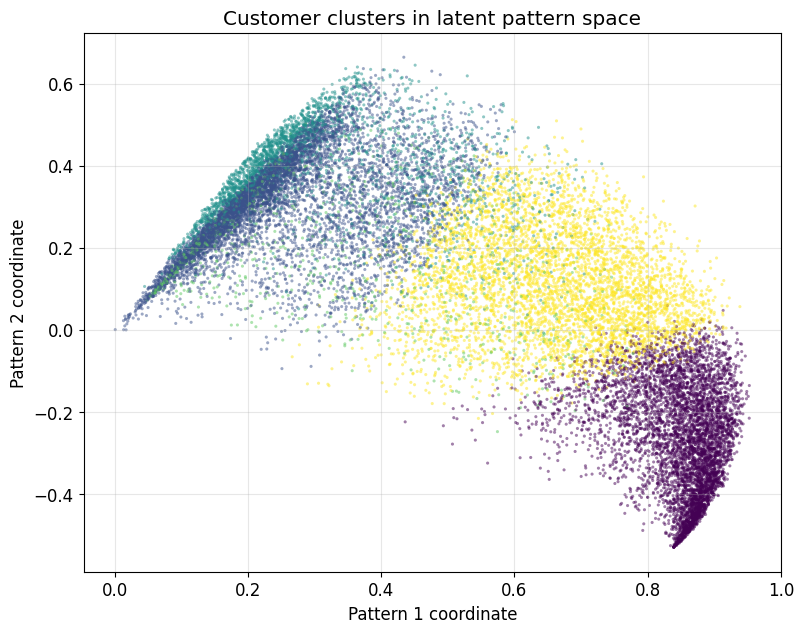

In [ ]:
from sklearn.cluster import KMeans

customer_features = U[:, :10] * sigma[:10]

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(customer_features)

plt.figure(figsize=(9, 7))
plt.scatter(
    coords[idx_sample, 0],
    coords[idx_sample, 1],
    c=clusters[idx_sample],
    s=5,
    alpha=0.5,
    linewidths=0
)
plt.xlabel('Pattern 1 coordinate')
plt.ylabel('Pattern 2 coordinate')
plt.title('Customer clusters in latent pattern space')
plt.grid(True, alpha=0.3)
plt.show()

## Clustering explanation

In [ ]:
cluster_df = pd.DataFrame({
    "customer_idx": np.arange(len(clusters)),
    "cluster": clusters
})

agg_with_cluster = agg.merge(cluster_df, on="customer_idx")

cluster_profile = (
    agg_with_cluster
    .groupby(["cluster", "category_idx"])["total_amount"]
    .mean()
    .unstack(fill_value=0)
)

TOP_N = 5

for cluster_id in cluster_profile.index:
    print(f"\n=== Cluster {cluster_id} ===")

    top_categories = (
        cluster_profile.loc[cluster_id]
        .sort_values(ascending=False)
        .head(TOP_N)
    )

    for cat_idx, val in top_categories.items():
        print(f"{idx_to_category.get(cat_idx, cat_idx)} : {val:.2f}")


=== Cluster 0 ===
201000002 : 2366847.20
143040202 : 683801.42
146050006 : 527859.88
123040001 : 513250.06
207011001 : 423134.28

=== Cluster 1 ===
Ignore : 24080047.79
208020104 : 2515045.74
118010101 : 2419127.27
143040202 : 1147166.79
146050002 : 660867.08

=== Cluster 2 ===
202010902 : 833984.22
104050001 : 527252.22
146050002 : 486507.19
143040202 : 482988.14
101020102 : 411254.10

=== Cluster 3 ===
123040001 : 1826018.59
201000002 : 807805.94
127030404 : 569510.81
104050001 : 538955.61
127040406 : 456213.65

=== Cluster 4 ===
201000002 : 874313.20
143040202 : 588139.55
104050001 : 468075.46
123040001 : 431582.92
143030102 : 423998.04


---
## Step 6 — Randomized vs. Exact SVD

In [ ]:
import time
from scipy.sparse.linalg import svds

ks_bench = [10, 50, 100, 200]
ks_bench = [k for k in ks_bench if k < min(A.shape)]  # safety

results = []

for k in ks_bench:
    t0 = time.time()
    Ur, sr, Vtr = randomized_svd(A, n_components=k, random_state=42)
    t_rand = time.time() - t0

    t0 = time.time()
    Ue, se, Vte = svds(A, k=k)
    t_exact = time.time() - t0

    # svds returns ascending values → reverse properly
    se_sorted = np.sort(se)[::-1]

    # FIX: ensure both are same length/order
    err = np.linalg.norm(sr - se_sorted) / np.linalg.norm(se_sorted)

    results.append({
        'k': k,
        't_rand': round(t_rand, 2),
        't_exact': round(t_exact, 2),
        'sigma_err': f'{err:.2e}'
    })

    print(f'k={k:4d}  rand={t_rand:.2f}s  exact={t_exact:.2f}s  sigma_err={err:.2e}')

pd.DataFrame(results)

k=  10  rand=14.19s  exact=4.69s  sigma_err=7.30e-13
k=  50  rand=27.78s  exact=13.22s  sigma_err=4.04e-06
k= 100  rand=35.02s  exact=24.90s  sigma_err=9.75e-06
k= 200  rand=73.12s  exact=56.68s  sigma_err=4.91e-06


,k,t_rand,t_exact,sigma_err
0,10,14.19,4.69,7.30e-13
1,50,27.78,13.22,4.04e-06
2,100,35.02,24.90,9.75e-06
3,200,73.12,56.68,4.91e-06


---
## Post-Analysis — Customer Portrait

In [ ]:
CLIENT_IDX = 0  # replace with index of interest

client_row = A[CLIENT_IDX].toarray().flatten()
top_sku_idx = np.argsort(client_row)[-10:][::-1]

print('Top purchases:')
for idx in top_sku_idx:
    print(f'  SKU {str(idx_to_category.get(idx, idx)):30s}  spend={client_row[idx]:.0f}')

print('\nPattern coordinates (first 5):')
for i in range(5):
    print(f'  Pattern {i+1}: {U[CLIENT_IDX, i] * sigma[i]:.3f}')

dominant = np.argmax(np.abs(U[CLIENT_IDX, :5] * sigma[:5]))
print(f'\nDominant pattern: {dominant + 1}')

print("\nInterpretation:")
print(f"Customer is mainly influenced by pattern {dominant+1},")
print("indicating a strong preference for specific product categories.")

Top purchases:
  SKU 160040101                       spend=278884
  SKU 158020201                       spend=159980
  SKU 128080302                       spend=151460
  SKU 152010102                       spend=99980
  SKU 201000002                       spend=94070
  SKU 118030005                       spend=89930
  SKU 122000018                       spend=87490
  SKU 160030102                       spend=71990
  SKU 120020008                       spend=68923
  SKU 140060101                       spend=65890

Pattern coordinates (first 5):
  Pattern 1: 0.379
  Pattern 2: 0.206
  Pattern 3: -0.048
  Pattern 4: -0.165
  Pattern 5: -0.183

Dominant pattern: 1

Interpretation:
Customer is mainly influenced by pattern 1,
indicating a strong preference for specific product categories.
